In [1]:
import pyabf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
'/Users/carlosguzman/Desktop/DATA/3_12_2026/26312001.abf'
'/Users/carlosguzman/Desktop/DATA/3-16-2026/26316000.abf'

'/Users/carlosguzman/Desktop/DATA/3-16-2026/26316000.abf'

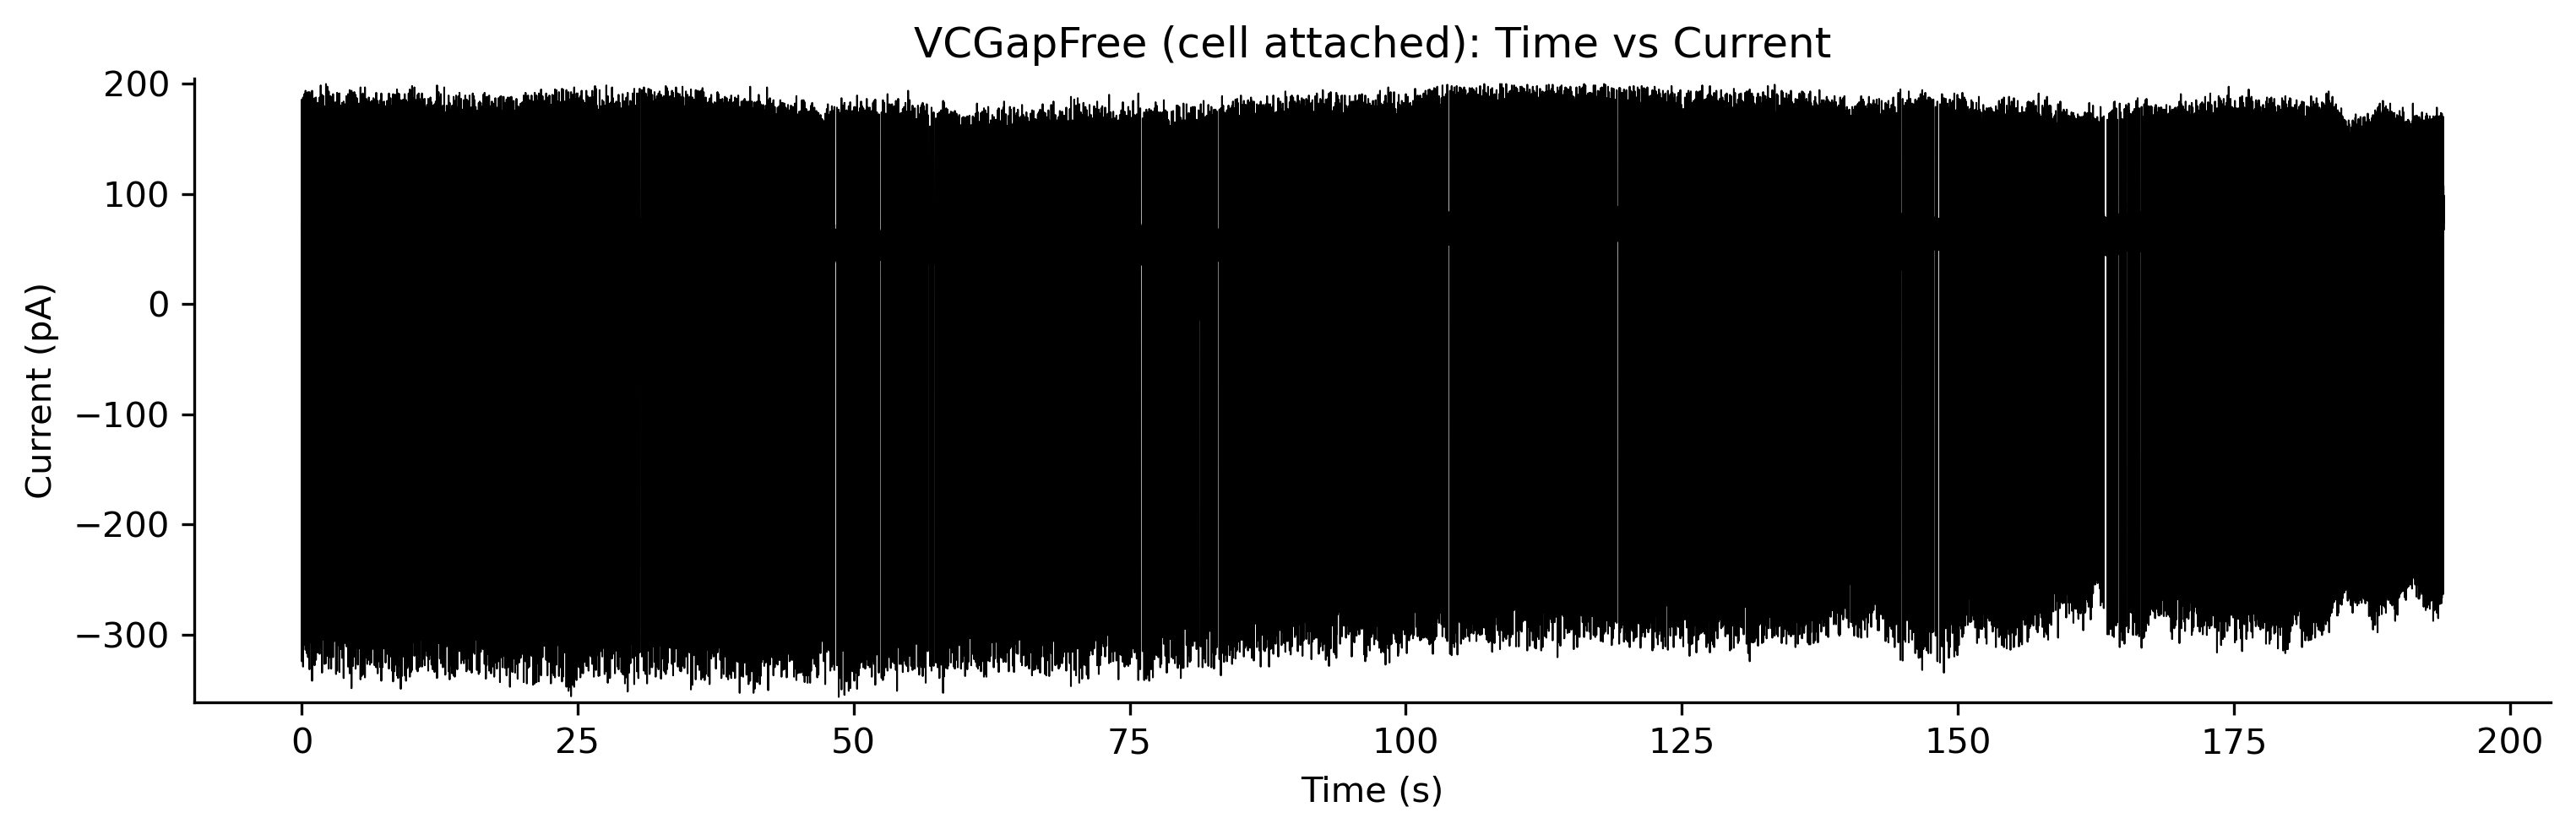

In [3]:
path_to_abf = '/Users/carlosguzman/Desktop/DATA/2_3_2026/26203015.abf'



time_strt = 0
time_end = 194 

up_thhld = 200
dwn_thhld = -600

spk_thhold= -150.00

plt_pad = 5.0
negative_spiking = True


# Helps reduce tiny noise crossings if needed later.
min_depth_pA_spike = 0.0                   # e.g. set to 2.0 or 5.0 if you get too many events

# Optional refractory filter to prevent double counts (ms); leave 0 for none
min_isi_ms_spike = 0.0                     # e.g. 1–2 ms if needed





# def VC_GapFree(path_to_abf, time_strt, time_end, up_thhld, dwn_thhld, spk_thhold, plt_pad)

# =========================
# Set main variables from params
# =========================

abf_VCGapFree = pyabf.ABF(path_to_abf)
abf_VCGapFree.setSweep(0)

t_start, t_end = time_strt, time_end  # analysis window (seconds usually)
upper_thresh = up_thhld               # artifact removal: drop y >= 50 pA
lower_thresh = dwn_thhld              # artifact removal: drop y <= -100 pA
threshold_pA = spk_thhold             # what pA must cross to be considered a spike
plt_currentAxis_pad = plt_pad
neg_spike = negative_spiking

#ISIH variables
min_depth_pA = min_depth_pA_spike              
min_isi_ms = min_isi_ms_spike          


# =========================
# Extract relevant data 
# =========================
# X = time (seconds)
time = abf_VCGapFree.sweepX          
# Y = current (pA)
current = abf_VCGapFree.sweepY
# Input Voltage we are holding in VC
voltage_hold = abf_VCGapFree.sweepC

# =========================
# Convert to Data Frame
# =========================
vc_original_df = pd.DataFrame({'time': time, 'current': current, 'voltage_holding': voltage_hold})
vc_cleaned_df = vc_original_df.loc[(vc_original_df['time'] >= t_start) & (vc_original_df['time'] <= t_end)]
vc_cleaned_df = vc_cleaned_df.loc[(vc_cleaned_df['current'] > lower_thresh) & (vc_cleaned_df['current'] < upper_thresh)]




# =========================
# Interspike Interval Histogram (ISIH) If wanted     
# ONLY CHANGE THIS SECTION
# =========================

# if negative_spiking = True
#passed_thrhlf_spike = vc_cleaned_df.loc[(vc_cleaned_df['current'] < spk_thhold)]
# else, isih_df = vc_cleaned_df.loc[(vc_cleaned_df['current'] > spk_thhold)]
# will need to invert method for positie spikes






# -----------------------------
# Plot Voltage Clamp Figure Clean
# -----------------------------
plt.figure(figsize=(12, 3.2), dpi=300)  
# Fill data with desired x (time) and y (current data points
plt.plot(vc_cleaned_df['time'], vc_cleaned_df['current'], color="black", linewidth=0.5)

# Optional: show spike threshold 
#plt.axhline(threshold_pA, color="red", linewidth=1.0, linestyle="--", label="Spike ThHd")
#plt.axvline(290, color="red", linewidth=1.0, linestyle="--")

# Titles / labels
plt.title(f"VCGapFree (cell attached): Time vs Current")
plt.xlabel("Time (s)")
plt.ylabel("Current (pA)")

# Apply axis limits
ymin_lim = vc_cleaned_df['current'].min() - plt_currentAxis_pad
ymax_lim = vc_cleaned_df['current'].max() + plt_currentAxis_pad

plt.ylim(ymin_lim, ymax_lim)

# Clean up spines for a figure look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Uncomment to save
# plt.savefig(f"REVISION_VC.svg", dpi=300)

plt.show()


In [4]:
abf_VCGapFree

ABF (v2.9) with 2 channels (pA, mV), sampled at 10.0 kHz, containing 1 sweep, having no tags, with a total length of 3.24 minutes, recorded with protocol "VCGapFree". path=/Users/carlosguzman/Desktop/DATA/2_3_2026/26203015.abf

In [5]:
# =========================
# Cell 4 (REPLACE ENTIRE CELL)
# Find event peaks (most negative for negative_spiking=True) and build events_df
# NOTE: This version correctly maps peaks back to vc_cleaned_df's (possibly non-contiguous) index.
# =========================

# Pull arrays from the cleaned dataframe (fast + consistent)
time_array = vc_cleaned_df["time"].to_numpy()
current_array = vc_cleaned_df["current"].to_numpy()

# Safety defaults in case something wasn't defined upstream
if "neg_spike" not in globals() and "neg_spike" not in locals():
    neg_spike = True  # default: negative-going events
if "min_depth_pA" not in globals() and "min_depth_pA" not in locals():
    min_depth_pA = 0.0
if "min_isi_ms" not in globals() and "min_isi_ms" not in locals():
    min_isi_ms = 0.0

# =========================
# 1) Identify threshold-crossing segments
#    - Negative spikes: segment = current < threshold_pA
#    - Positive spikes: segment = current > threshold_pA
# =========================
if neg_spike:
    in_event = current_array < threshold_pA
else:
    in_event = current_array > threshold_pA

# Find segment boundaries via edge detection on the boolean array
edges = np.diff(in_event.astype(np.int8))
starts = np.where(edges == 1)[0] + 1
ends   = np.where(edges == -1)[0] + 1

# Handle segments that start at index 0 or end at final index
if in_event.size and in_event[0]:
    starts = np.r_[0, starts]
if in_event.size and in_event[-1]:
    ends = np.r_[ends, in_event.size]

# =========================
# 2) For each segment, find the peak (min for negative, max for positive)
#    Apply optional "depth" filter to reject tiny threshold grazes.
# =========================
peak_indices = []

for s, e in zip(starts, ends):
    if e <= s:
        continue

    seg = current_array[s:e]
    if seg.size == 0:
        continue

    if neg_spike:
        peak_val = np.min(seg)  # most negative point in the segment

        # Depth requirement: peak must be at least min_depth_pA below threshold
        # (e.g. threshold 0 pA, min_depth_pA 2 -> require peak <= -2 pA)
        if peak_val > (threshold_pA - min_depth_pA):
            continue

        # Handle plateaus by taking the mean position of all equal minima
        rel_positions = np.where(seg == peak_val)[0]
    else:
        peak_val = np.max(seg)  # most positive point in the segment

        # Depth requirement: peak must be at least min_depth_pA above threshold
        if peak_val < (threshold_pA + min_depth_pA):
            continue

        rel_positions = np.where(seg == peak_val)[0]

    peak_rel = int(np.round(rel_positions.mean()))
    peak_idx = s + peak_rel
    peak_indices.append(peak_idx)

peak_indices = np.array(peak_indices, dtype=int)

# If nothing found, return an empty events_df with expected columns
if peak_indices.size == 0:
    events_df = pd.DataFrame(columns=["peak_time", "peak_current_pA", "index_in_cleaned", "global_index"])
else:
    # Convert indices to time/current at those exact indices
    peak_times = time_array[peak_indices]
    peak_currents = current_array[peak_indices]

    # =========================
    # 3) Optional refractory period filtering (prevents double-counts)
    # =========================
    if min_isi_ms > 0 and peak_times.size > 1:
        min_isi_sec = min_isi_ms / 1000.0
        keep = [0]
        for i in range(1, peak_times.size):
            if (peak_times[i] - peak_times[keep[-1]]) >= min_isi_sec:
                keep.append(i)
        keep = np.array(keep, dtype=int)

        peak_indices = peak_indices[keep]
        peak_times = peak_times[keep]
        peak_currents = peak_currents[keep]

    # =========================
    # 4) Build events_df
    #    IMPORTANT: map peak_indices (positional) -> the actual index values in vc_cleaned_df
    # =========================
    cleaned_index = vc_cleaned_df.index.to_numpy()
    global_index = cleaned_index[peak_indices]

    events_df = pd.DataFrame({
        "peak_time": peak_times,
        "peak_current_pA": peak_currents,
        "index_in_cleaned": peak_indices,   # 0..N-1 positional index into vc_cleaned_df arrays
        "global_index": global_index        # actual df index used in Cell 5
    })


In [6]:
# Add to cleaned dataframe as boolean column
#vc_cleaned_df = vc_cleaned_df.copy()
vc_cleaned_df['is_event_peak'] = False
vc_cleaned_df.loc[events_df['global_index'], 'is_event_peak'] = True


In [7]:
vc_cleaned_df

,time,current,voltage_holding,is_event_peak
0,0.0000,64.697266,0.0,False
1,0.0001,71.411133,0.0,False
2,0.0002,61.645508,0.0,False
3,0.0003,59.814453,0.0,False
4,0.0004,61.645508,0.0,False
...,...,...,...,...
1939996,193.9996,83.618164,0.0,False
1939997,193.9997,92.773438,0.0,False
1939998,193.9998,77.514648,0.0,False
1939999,193.9999,84.838867,0.0,False


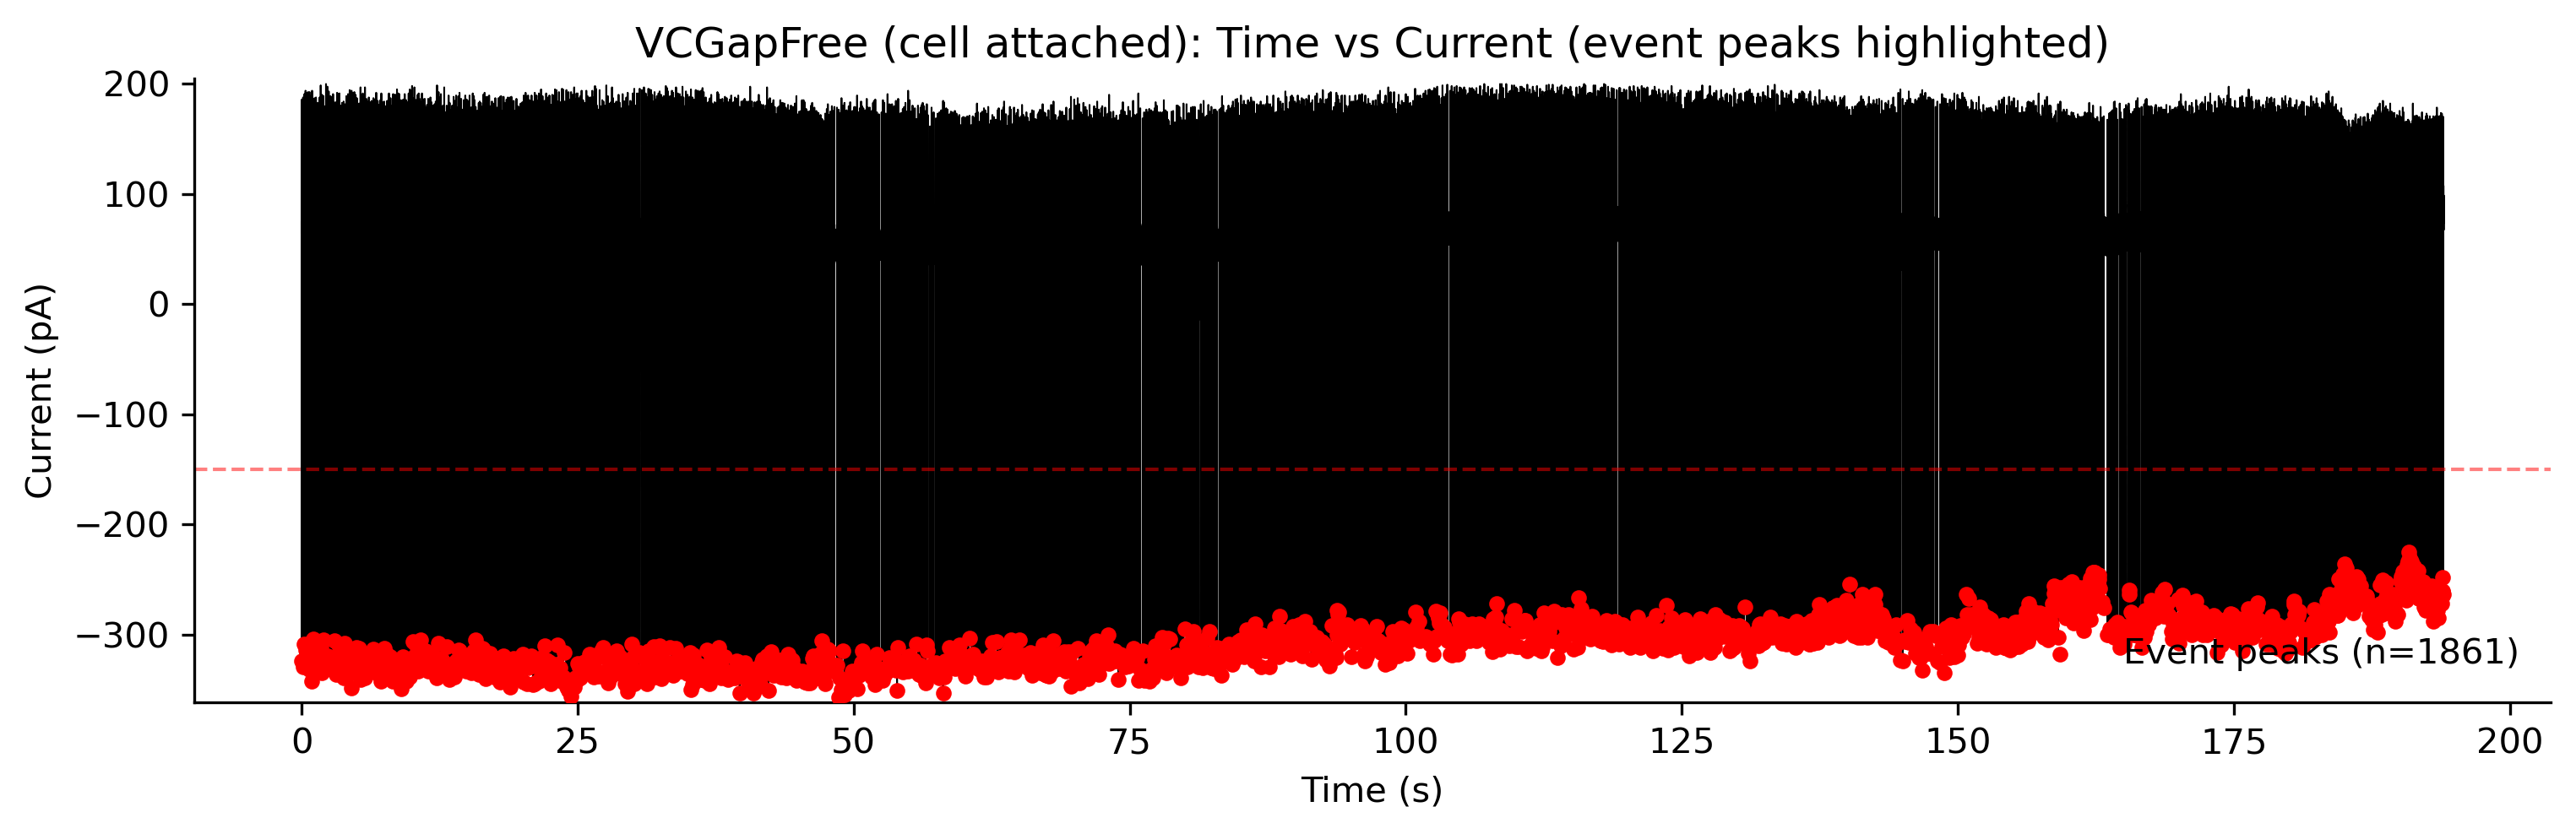

In [8]:
# =========================
# Plot VC trace + event peaks (red)
# =========================

peaks_df = vc_cleaned_df.loc[vc_cleaned_df["is_event_peak"]]

fig, ax = plt.subplots(figsize=(12, 3.2), dpi=300)

# Main trace
ax.plot(
    vc_cleaned_df["time"],
    vc_cleaned_df["current"],
    color="black",
    linewidth=0.5,
    zorder=1
)

# Overlay event peaks
ax.scatter(
    peaks_df["time"],
    peaks_df["current"],
    color="red",
    s=12,            # marker size (points^2)
    zorder=3,
    label=f"Event peaks (n={len(peaks_df)})"
)

# Optional: threshold line
ax.axhline(threshold_pA, color="red", linewidth=1.0, linestyle="--", alpha=0.5)

# Labels / formatting
ax.set_title("VCGapFree (cell attached): Time vs Current (event peaks highlighted)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (pA)")

ymin_lim = vc_cleaned_df["current"].min() - plt_currentAxis_pad
ymax_lim = vc_cleaned_df["current"].max() + plt_currentAxis_pad

# Time of switch
#plt.axvline(480, color="red", linewidth=1.0, linestyle="--")

ax.set_ylim(ymin_lim, ymax_lim)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="lower right")
plt.show()


In [9]:
events_df

,peak_time,peak_current_pA,index_in_cleaned,global_index
0,0.0314,-324.096680,314,314
1,0.1386,-328.979492,1386,1386
2,0.2624,-308.837891,2624,2624
3,0.3595,-313.720703,3595,3595
4,0.4654,-316.772461,4654,4654
...,...,...,...,...
1856,193.8299,-266.723633,1938267,1938299
1857,193.8714,-260.009766,1938682,1938714
1858,193.9049,-261.230469,1939017,1939049
1859,193.9308,-247.802734,1939276,1939308


In [10]:
# Add ISI (seconds): time to next peak
# Last event has no next peak -> NaN
events_df = events_df.sort_values("peak_time").reset_index(drop=True)
events_df["ISI"] = events_df["peak_time"].shift(-1) - events_df["peak_time"]


In [11]:
mean_val_isi = events_df['ISI'].mean()

events_df

,peak_time,peak_current_pA,index_in_cleaned,global_index,ISI
0,0.0314,-324.096680,314,314,0.1072
1,0.1386,-328.979492,1386,1386,0.1238
2,0.2624,-308.837891,2624,2624,0.0971
3,0.3595,-313.720703,3595,3595,0.1059
4,0.4654,-316.772461,4654,4654,0.1205
...,...,...,...,...,...
1856,193.8299,-266.723633,1938267,1938299,0.0415
1857,193.8714,-260.009766,1938682,1938714,0.0335
1858,193.9049,-261.230469,1939017,1939049,0.0259
1859,193.9308,-247.802734,1939276,1939308,0.0329


In [12]:
# Instantaneous frequency (Hz) = 1 / ISI (s)
# Keep NaN for last event, and avoid division by zero
events_df["instant_frequency"] = np.where(
    events_df["ISI"] > 0,
    1.0 / events_df["ISI"],
    np.nan
)



In [13]:
mean_val_intaFreq = events_df['instant_frequency'].mean()
events_df

,peak_time,peak_current_pA,index_in_cleaned,global_index,ISI,instant_frequency
0,0.0314,-324.096680,314,314,0.1072,9.328358
1,0.1386,-328.979492,1386,1386,0.1238,8.077544
2,0.2624,-308.837891,2624,2624,0.0971,10.298661
3,0.3595,-313.720703,3595,3595,0.1059,9.442871
4,0.4654,-316.772461,4654,4654,0.1205,8.298755
...,...,...,...,...,...,...
1856,193.8299,-266.723633,1938267,1938299,0.0415,24.096386
1857,193.8714,-260.009766,1938682,1938714,0.0335,29.850746
1858,193.9049,-261.230469,1939017,1939049,0.0259,38.610039
1859,193.9308,-247.802734,1939276,1939308,0.0329,30.395137


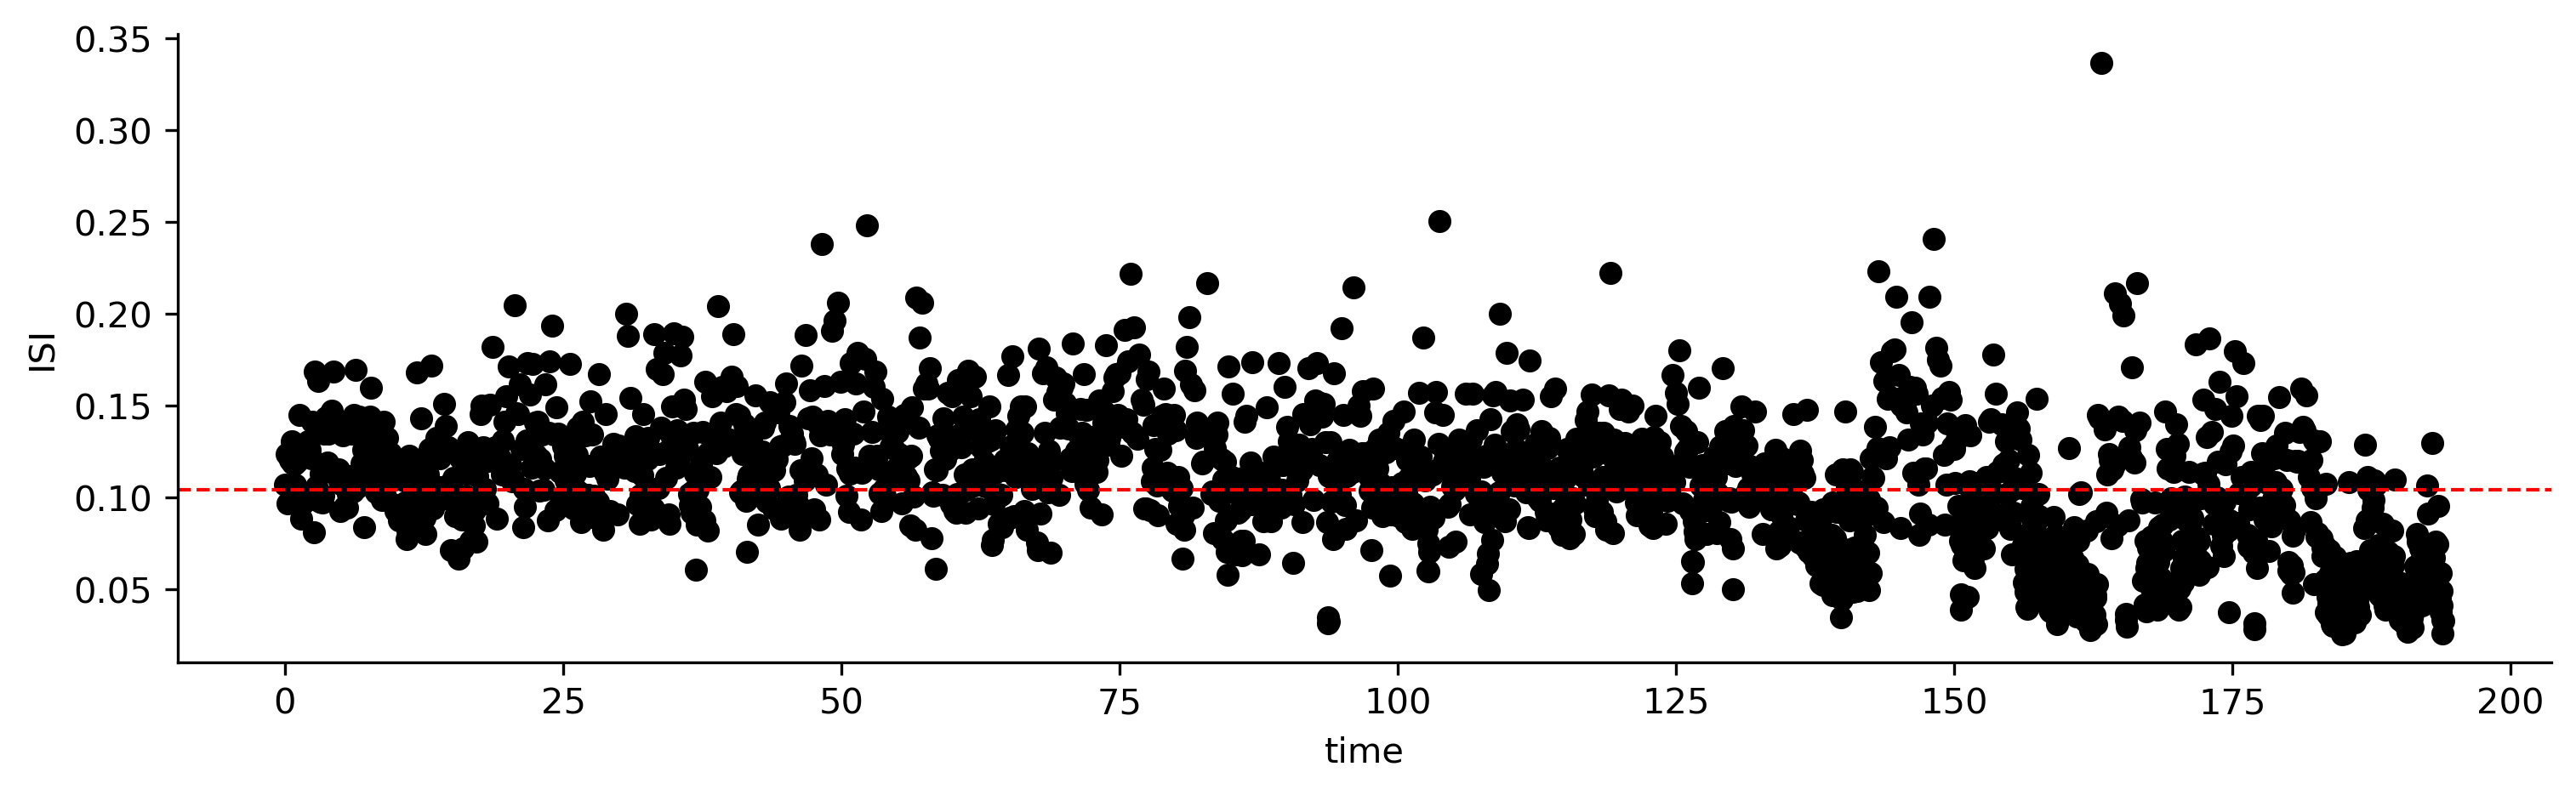

In [14]:
#plt.scatter(events_df['peak_time'], events_df['ISI'])
#plt.xlabel('time')
#plt.ylabel('ISI')
#plt.show()

df_filtered = events_df[events_df['ISI'] > 0.01]

plt.figure(figsize=(12, 3.2), dpi=300)  
# Fill data with desired x (time) and y (current data points
plt.scatter(events_df['peak_time'], events_df['ISI'], color="black", linewidth=0.5)
plt.xlabel('time')
plt.ylabel('ISI')
# Optional: show mean hz and drug start
plt.axhline(mean_val_isi, color="red", linewidth=1.0, linestyle="--")
#plt.axvline(160, color="red", linewidth=1.0, linestyle="--")

# Clean up spines for a figure look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Uncomment to save
# plt.savefig(f"REVISION_VC.svg", dpi=300)

plt.show()


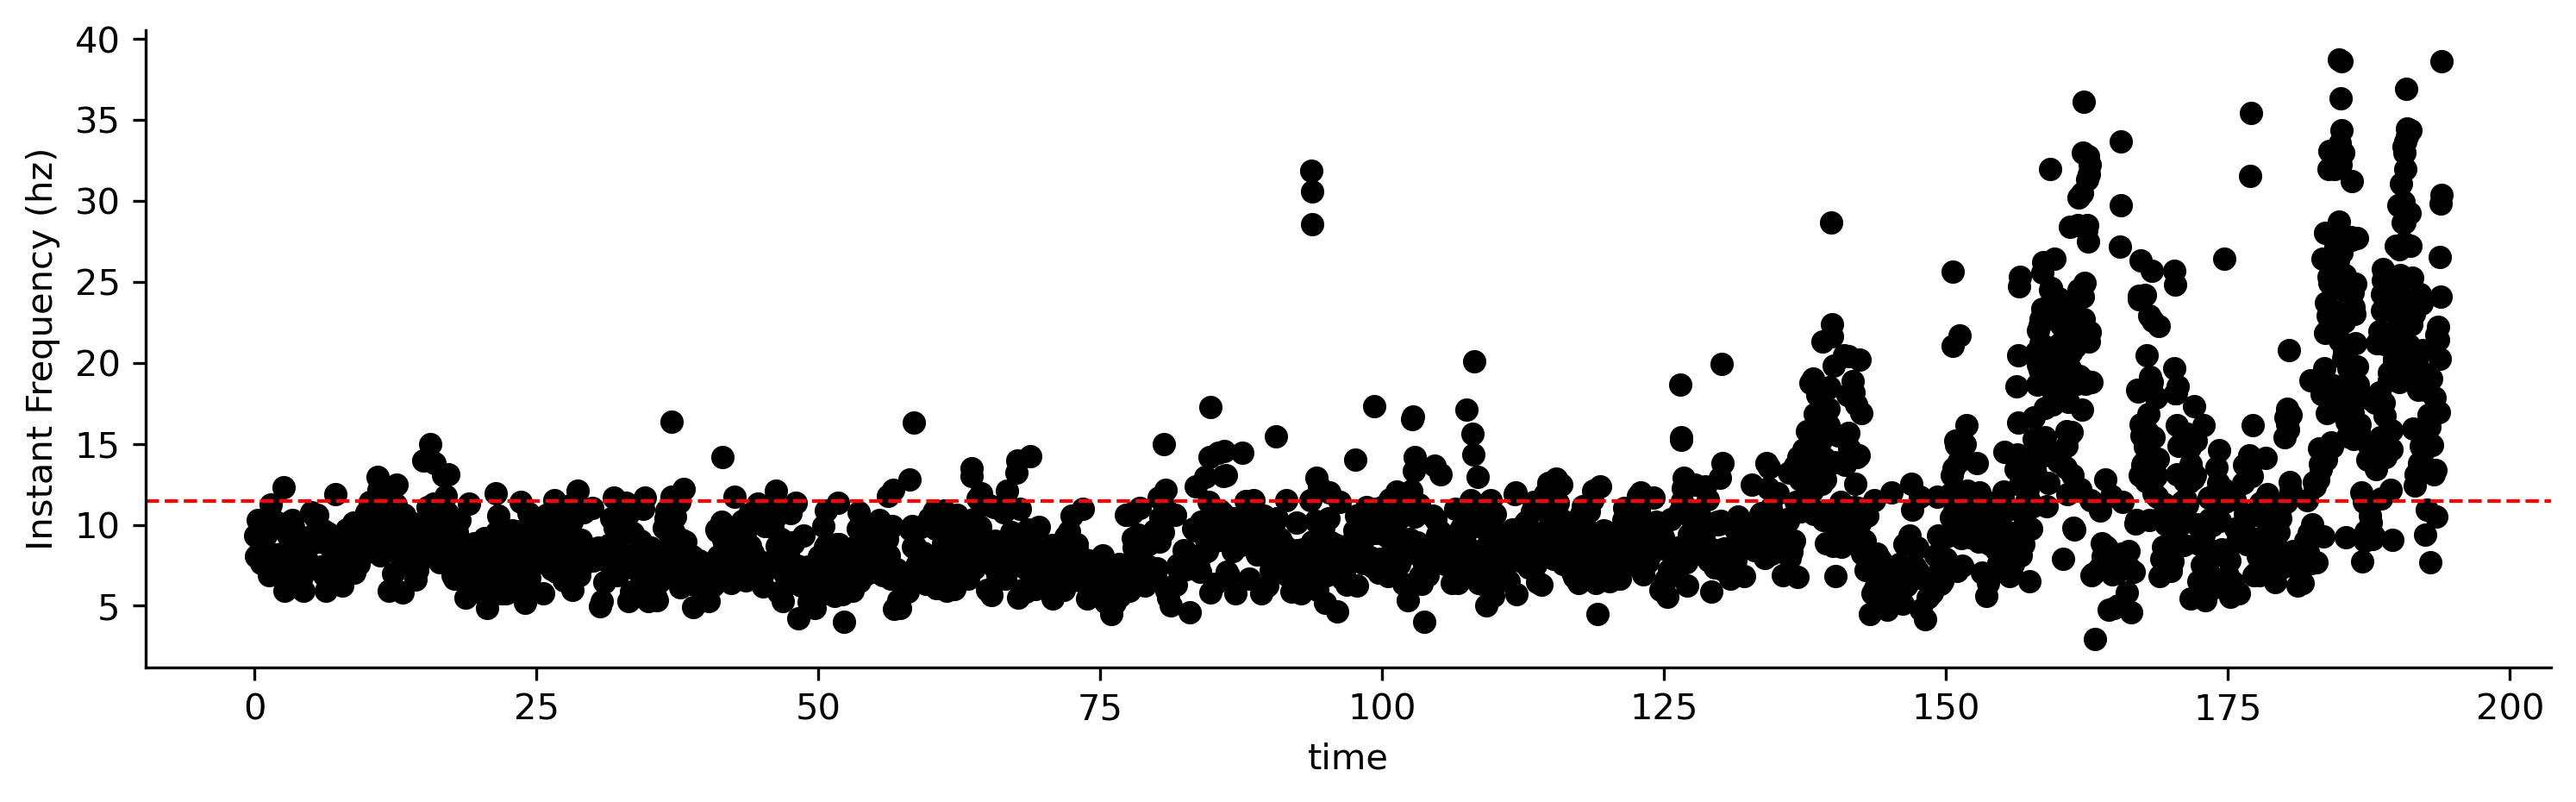

In [15]:
df_filtered = events_df[events_df['instant_frequency'] < 4000]
#df_filtered = events_df

#plt.scatter(df_filtered['peak_time'], df_filtered['instant_frequency'])
#plt.xlabel('time')
#plt.ylabel('instant_frequency')
#plt.show()


plt.figure(figsize=(12, 3.2), dpi=300)  
# Fill data with desired x (time) and y (current data points
plt.scatter(df_filtered['peak_time'], df_filtered['instant_frequency'], color="black", linewidth=0.5)
plt.xlabel('time')
plt.ylabel('Instant Frequency (hz)')

# Optional: show mean hz and drug start
mean_val_intaFreq = df_filtered['instant_frequency'].mean()
plt.axhline(mean_val_intaFreq, color="red", linewidth=1.0, linestyle="--")
#plt.axvline(290, color="red", linewidth=1.0, linestyle="--")
#plt.ylim(0, 20)
# Clean up spines for a figure look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Uncomment to save
#plt.savefig(f"Drugg.svg", dpi=300)

plt.show()

In [16]:

df_filtered.loc[df_filtered['instant_frequency'].idxmax()]

peak_time            1.848675e+02
peak_current_pA     -2.667236e+02
index_in_cleaned     1.848644e+06
global_index         1.848675e+06
ISI                  2.580000e-02
instant_frequency    3.875969e+01
Name: 1693, dtype: float64

In [17]:
df_filtered['ISI'].mean()

np.float64(0.10426467741935484)

In [18]:
df_filtered['instant_frequency'].mean()

np.float64(11.484534129633145)